<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Filtragem Adaptativa</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 26 de dezembro de 2025
</div>

<div style="page-break-after: always;"></div>

<style>
#toc ol {
  counter-reset: item;
  list-style-type: none;
  padding-left: 1.2em;
}
#toc li {
  display: block;
}
#toc li:before {
  content: counters(item, ".") " ";
  counter-increment: item;
}
</style>

<div id="toc">
  <h2>Sumário</h2>
  <ol>
    <li><a href="#1-introdução">Introdução</a></li>
    <li>
      <a href="#2-desenvolvimento">Desenvolvimento</a>
      <ol>
          <li><a href="#21-LMS">Algoritmo LMS</a></li>
          <li><a href="#22-simulacao1">Erro Quadrático por iteração</a></li>
          <li><a href="#23-simulacao2">MSE e variância em regime permanente vs SNR</a></li>
      </ol>
    </li>
    <li>
      <a href="#3-resultados-e-discussões">Resultados e discussões</a>
      <ol>
          <li><a href="#31-simulacao1">Erro Quadrático por iteração</a></li>
          <li><a href="#32-simulacao2">MSE e variância em regime permanente vs SNR</a></li>
      </ol>
    </li>
    <li><a href="#referencias">Referências</a></li>
  </ol>
</div>

<div style="page-break-after: always;"></div>

<a id="1-introdução"></a>
# 1. Introdução

Em diversos problemas de processamento digital de sinais, as características do ambiente de transmissão ou do sistema sob análise não são completamente conhecidas a priori, ou podem variar ao longo do tempo. Nessas situações, o uso de filtros adaptativos torna-se uma ferramenta fundamental, pois permite que o próprio sistema ajuste seus coeficientes de forma automática, com base em um critério de desempenho, visando minimizar o erro entre um sinal desejado e a saída do filtro.

Entre os algoritmos de adaptação mais utilizados, destaca-se o algoritmo LMS (*Least Mean Squares*), devido à sua simplicidade computacional, robustez e ampla aplicação prática. O LMS realiza a adaptação iterativa dos coeficientes do filtro a partir da minimização do erro médio quadrático (MSE), utilizando uma aproximação estocástica do gradiente da função custo. O comportamento do algoritmo depende do passo de adaptação e das propriedades estatísticas do sinal de entrada, que influenciam diretamente a velocidade de convergência e o erro em regime permanente.

Neste notebook, o algoritmo LMS é aplicado como equalizador em um sistema de comunicação digital em banda base. O sistema considerado inclui a geração de símbolos BPSK, conformação de pulso, passagem por um canal com resposta em frequência passa-baixas, adição de ruído branco gaussiano e filtragem casada no receptor. O equalizador adaptativo opera na taxa de símbolos, buscando mitigar os efeitos do canal e do ruído.

A análise de desempenho do LMS é conduzida a partir da observação do erro quadrático ao longo das iterações, permitindo a investigação do processo de convergência do algoritmo. Além disso, são avaliadas métricas estatísticas em regime permanente, como o valor médio do erro médio quadrático (MSE) e a variância do erro, para diferentes valores do passo de adaptação e da razão sinal-ruído (SNR).


<a id="2-desenvolvimento"></a>
# 2. Desenvolvimento

<a id="21-LMS"></a>
## 2.1 Algoritmo LMS

A filtragem adaptativa tem como objetivo ajustar automaticamente os coeficientes de um filtro digital de forma a otimizar um determinado critério de desempenho, normalmente relacionado ao erro entre a saída do filtro e um sinal de referência. Diferentemente dos filtros de coeficientes fixos, os filtros adaptativos são capazes de acompanhar variações estatísticas do sinal de entrada ou do sistema a ser modelado, sendo amplamente empregados em aplicações como equalização de canais, cancelamento de eco e supressão de ruído.

Considere um filtro adaptativo FIR de ordem $N-1$, cuja saída no instante discreto $k$ é dada por

$$
y[k] = \mathbf{h}^T[k]\mathbf{x}[k],
$$

em que $\mathbf{h}[k] = [h_0[k], h_1[k], \ldots, h_{N-1}[k]]^T$ é o vetor de coeficientes do filtro no instante $k$, e $\mathbf{x}[k] = [x[k], x[k-1], \ldots, x[k-N+1]]^T$ é o vetor de amostras de entrada.

Define-se o erro instantâneo como a diferença entre o sinal desejado $d[k]$ e a saída do filtro:

$$
e[k] = d[k] - y[k].
$$

O critério clássico adotado na filtragem adaptativa é a minimização do erro médio quadrático (MSE), definido como

$$
J(\mathbf{h}) = \mathbb{E}\{e^2[k]\}.
$$

A solução ótima que minimiza essa função custo é dada pela solução de Wiener, que depende do conhecimento das estatísticas de segunda ordem do sinal de entrada e da correlação cruzada com o sinal desejado. No entanto, em muitos cenários práticos, essas estatísticas não são conhecidas ou variam no tempo, inviabilizando o uso direto da solução ótima.

O algoritmo LMS (*Least Mean Squares*) surge como uma alternativa de baixa complexidade ao substituir o gradiente exato da função custo por uma estimativa instantânea. A partir do método do gradiente descendente, a atualização dos coeficientes pode ser escrita como

$$
\mathbf{h}[k+1] = \mathbf{h}[k] - \mu \nabla J(\mathbf{h}[k]),
$$

onde $\mu$ é o passo de adaptação. No LMS, o gradiente do MSE é aproximado por

$$
\nabla J(\mathbf{h}[k]) \approx -2 e[k]\mathbf{x}[k],
$$

resultando na regra de atualização característica do algoritmo:

$$
\mathbf{h}[k+1] = \mathbf{h}[k] + \mu e[k]\mathbf{x}[k].
$$

Essa equação mostra que os coeficientes do filtro são ajustados iterativamente a cada amostra, na direção que reduz o erro quadrático instantâneo. O parâmetro $\mu$ controla o comportamento do algoritmo: valores maiores proporcionam convergência mais rápida, porém aumentam as oscilações em torno da solução ótima e podem levar à instabilidade; valores menores resultam em convergência mais lenta, porém com menor erro em regime permanente.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from scipy.signal import freqz

from optic.dsp.core import firFilter, pulseShape, lowPassFIR, pnorm, decimate, upsample, signalPower
from optic.plot import eyediagram
from optic.utils import parameters

plt.style.use('seaborn-v0_8')

In [2]:
@njit
def LMS_equalizer(input_signal, desired_signal, mu, num_taps):
    """
    Implements an LMS adaptive equalizer.

    Parameters:
        input_signal: array-like
            The input signal to be equalized.
        desired_signal: array-like
            The desired output signal.
        mu: float
            The step size for the LMS algorithm.
        num_taps: int
            The number of taps (filter coefficients) in the equalizer.
    
    Returns:
        output_signal: array-like
            The equalized output signal.
        error_signal: array-like
            The error signal (difference between desired and output).
        weights: array-like
            The final weights of the equalizer.
    """
    h = np.zeros(num_taps)
    output_signal = np.zeros(len(input_signal))
    MSE = np.zeros(len(input_signal))
    
    for k in range(num_taps, len(input_signal)):
        x_k = input_signal[k-np.arange(num_taps)]
        y = np.dot(h, x_k)
        e = desired_signal[k]-y
        
        h = h + mu*e*x_k
        MSE[k] = e**2
        output_signal[k] = y

    return output_signal, MSE, h

<a id="22-simulacao1"></a>
## 2.2 Erro quadrático por iteração

No contexto de equalização adaptativa, o sinal de entrada do LMS corresponde à sequência de símbolos recebidos após o canal e o receptor, enquanto o sinal desejado é a sequência de símbolos transmitidos. O equalizador adapta seus coeficientes de modo a compensar os efeitos da resposta impulsiva do canal e do ruído, reduzindo a interferência intersimbólica e aproximando a saída do filtro do sinal originalmente transmitido. Esse sistema é simulado de forma a analisar-se o erro quadrático ao longo das iterações de forma gráfica.

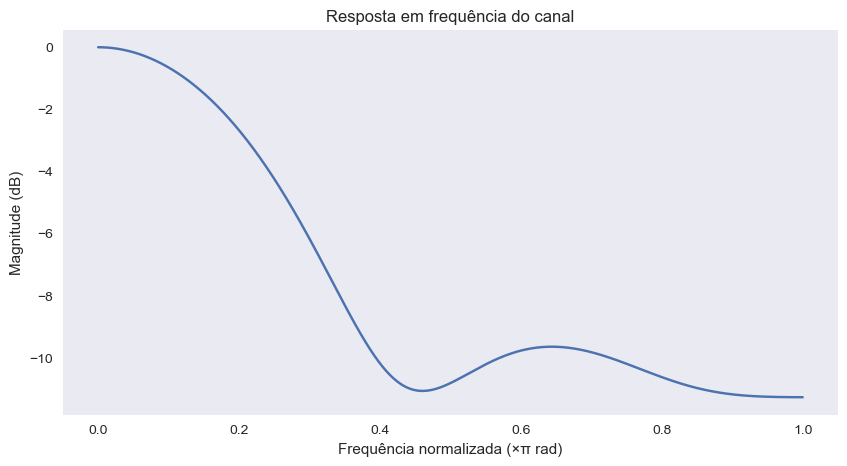

In [3]:
SpS = 4
mu = 0.001
num_taps = 6

# Decimation parameters
paramDec = parameters()
paramDec.SpSin = SpS
paramDec.SpSout = 1

# Pulse shaping parameters
paramPulse = parameters()
paramPulse.pulseType = 'rect' 
paramPulse.SpS = SpS     

# Generate random BPSK symbols and shape them
symbols = np.random.choice([-1, 1], size=100000)
pulse_shape = pulseShape(paramPulse)

upsampled_symbols = upsample(symbols, SpS)
transmitted_signal = np.convolve(upsampled_symbols, pulse_shape, mode = 'same')

channel = np.array([0.9, 0.5, 0.4, 0.3, 0.1])
channel = channel/np.sum(channel)
w, H = freqz(channel, worN=2048)

plt.figure(figsize=(10,5))
plt.plot(w/np.pi, 20*np.log10(np.abs(H)))
plt.xlabel('Frequência normalizada (×π rad)')
plt.ylabel('Magnitude (dB)')
plt.title('Resposta em frequência do canal')
plt.grid()
plt.show()

# Simulate transmission through the channel with noise
received_signal = np.convolve(transmitted_signal, channel, mode = 'same')
received_signal = np.roll(received_signal, 1)

noise = np.random.normal(0, 0.05, len(received_signal))
received_signal += noise
rx = np.convolve(received_signal, pulse_shape[::-1], 'same')

# Downsample the received signal to symbol rate
rx_sym = decimate(rx, paramDec)
rx_sym = pnorm(rx_sym)

out, mse, h = LMS_equalizer(rx_sym, symbols, mu, num_taps)

<a id="23-simulacao2"></a>
## 2.3 MSE e variância em regime permanente vs SNR

Nessa segunda simulação, pretende-se analisar o comportamento do algoritmo ao variar as características do canal, especificamente o ruído adicionado ao sinal, e o passo de iteração $\mu$. A simulação consiste no mesmo sistema utilizado previamente. Os resultados são ilustrados de forma gráfica.

In [6]:
SpS = 4
num_taps = 6
mus = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
SNR_dB = np.arange(5, 36, 1)
SNR_db_lc = 20
mus_lc = [0.001, 0.01]

Ns = 500000
discard = 50000  # transient removal
discard001 = 150000  # transient removal for mu=0.001

# Decimation parameters
paramDec = parameters()
paramDec.SpSin = SpS
paramDec.SpSout = 1

# Pulse shaping parameters
paramPulse = parameters()
paramPulse.pulseType = 'rect'
paramPulse.SpS = SpS

pulse_shape = pulseShape(paramPulse)

channel = np.array([0.9, 0.5, 0.4, 0.3, 0.1])
channel = channel / np.sum(channel)

# Generate random BPSK symbols and shape them
symbols = np.random.choice([-1, 1], size=Ns)
upsampled = upsample(symbols, SpS)
tx = np.convolve(upsampled, pulse_shape, mode='same')

MSE_results = np.zeros((len(mus), len(SNR_dB)))
VAR_results = np.zeros((len(mus), len(SNR_dB)))

for i_mu, mu in enumerate(mus):
    print(f"Running μ = {mu}")
    
    for i_snr, snr_db in enumerate(SNR_dB):

        # Channel (deterministic part)
        rx = np.convolve(tx, channel, mode='same')
        rx = np.roll(rx, 1)

        # Matched filter
        rx = np.convolve(rx, pulse_shape[::-1], mode='same')

        # Symbol recovery
        rx_sym_clean = decimate(rx, paramDec)

        # Signal power at LMS input
        Ps = np.mean(rx_sym_clean**2)

        # Noise variance from SNR
        snr_lin = 10**(snr_db / 10)
        sigma2 = Ps / snr_lin

        # Add noise at symbol rate
        noise = np.random.normal(0, np.sqrt(sigma2), len(rx_sym_clean))
        rx_sym = rx_sym_clean + noise

        # LMS
        out, e2_inst, h = LMS_equalizer(rx_sym, symbols, mu, num_taps)

        # Steady-state region
        if(mu == 0.001):
            e_ss = symbols[discard001:] - out[discard001:]
        else:
            e_ss = symbols[discard:] - out[discard:]

        
        MSE_results[i_mu, i_snr] = np.mean(e_ss**2)
        VAR_results[i_mu, i_snr] = np.var(e_ss)


Running μ = 0.001
Running μ = 0.005
Running μ = 0.01
Running μ = 0.05
Running μ = 0.1
Running μ = 0.5


<a id="3-resultados-e-discussões"></a>
## 3 Resultados e Discussões

<a id="31-simulacao1"></a>
## 3.1 Erro quadrático por iteração

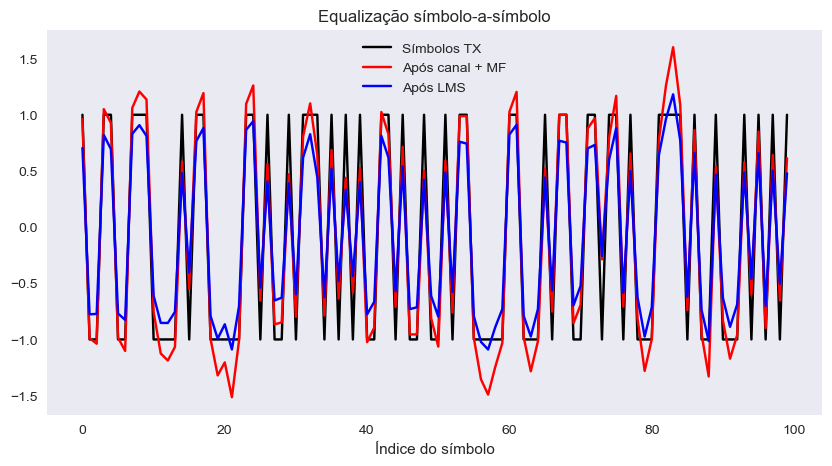

In [4]:
N = 1500
plt.figure(figsize=(10,5))
plt.plot(symbols[N:N+100], '-k', label='Símbolos TX')
plt.plot(rx_sym[N:N+100], '-r', label='Após canal + MF')
plt.plot(out[N:N+100], '-b', label='Após LMS')
plt.legend()
plt.grid()
plt.title('Equalização símbolo-a-símbolo')
plt.xlabel('Índice do símbolo')
plt.show()

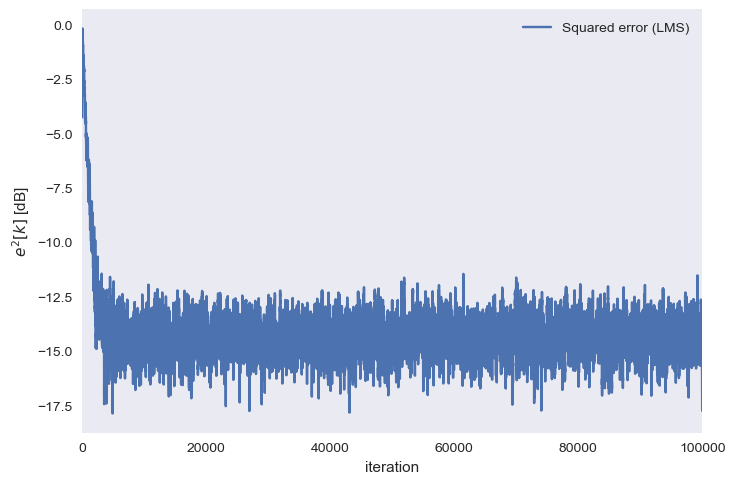

In [5]:
average_window_len = 50
error_dB = 10*np.log10(np.convolve(mse,np.ones(average_window_len)/average_window_len, 'same'))

plt.plot(error_dB, label='Squared error (LMS)')
plt.xlim(0,len(error_dB))
plt.xlabel('iteration')
plt.ylabel('$e^2[k]$ [dB]')
plt.legend()
plt.grid()

---
Os resultados ilustram a convergência do algoritmo como equalizador do sistema simulado, de modo que pode-se observar como o erro quadrático decresce rapidamente, e então passa a oscilar em torne de um valor próximo a $-15 \mathrm{dB}$. Oscilações estas relacionadas à natureza estocástica do canal e ao passo de adaptação utilizado no algoritmo. Essa dependÊncia é melhor analisada na próxima seção.

<a id="32-simulacao2"></a>
## 3.2 MSE e variância em regime permanente vs SNR

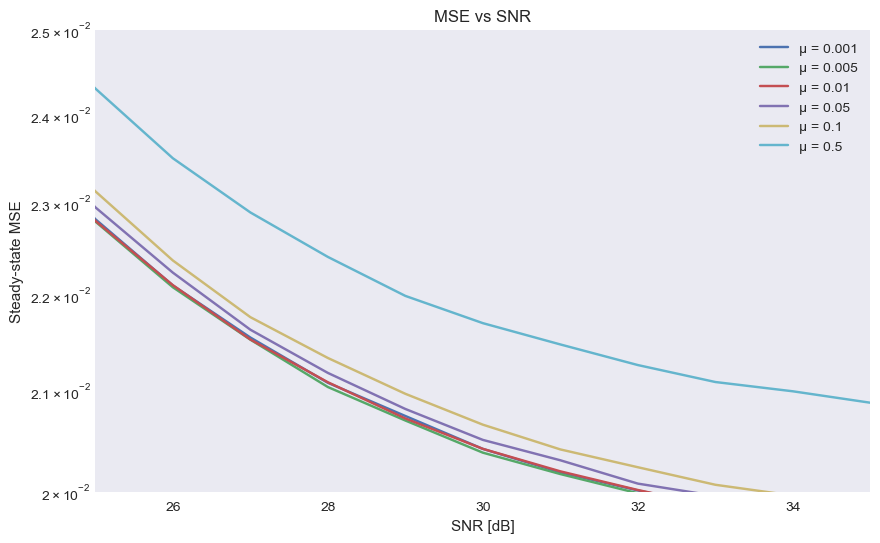

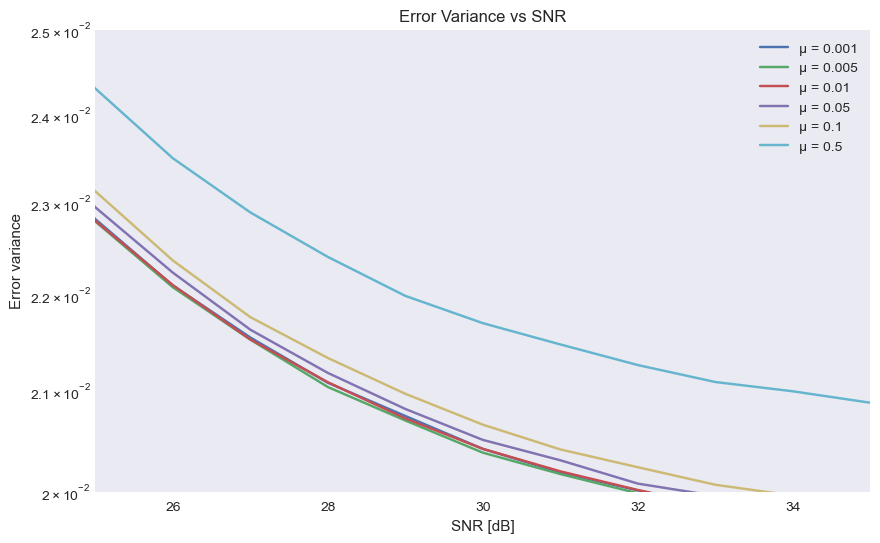

In [7]:
plt.figure(figsize=(10, 6))
for i, mu in enumerate(mus):
    plt.semilogy(SNR_dB, MSE_results[i], label=f'μ = {mu}')
plt.grid()
plt.xlabel('SNR [dB]')
plt.xlim(25, 35)
plt.ylabel('Steady-state MSE')
plt.ylim(2e-2, 2.5e-2)
plt.title('MSE vs SNR')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for i, mu in enumerate(mus):
    plt.semilogy(SNR_dB, VAR_results[i], label=f'μ = {mu}')
plt.grid()
plt.xlabel('SNR [dB]')
plt.xlim(25, 35)
plt.ylabel('Error variance')
plt.ylim(2e-2, 2.5e-2)
plt.title('Error Variance vs SNR')
plt.legend()
plt.show()

---
Os resultados ilustrados indicam que tanto o erro médio quadrático como a variância do erro em regime permanente diminuem conforma se eleva a SNR. Além disso, pode-se notar que essas métricas pioram consideravelmente para valores de passo $\mu$ mais elevados, convergindo para valores mais altos de erro médio e variância.